In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import sweetviz as sv
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 02 CFPB Exploratory Data Analysis (EDA)

Objective: profile the 300k stratified sample, surface dominant complaint patterns, and document key geography-based differences that motivate the time-series analysis in notebooks 03-04.

In [3]:
# Loading my 300k sample data
df = pd.read_parquet("../data/processed/cfpb_sample_300k.parquet")

In [5]:
print(f"Loaded {len(df):,} rows & {len(df.columns)} columns")

df.head()

Loaded 300,000 rows & 23 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,year_quarter,geo,region,stratum,sample_n
0,2012-03-14,Bank account or service,Checking account,"Making/receiving payments, sending money",None,None,None,"BANK OF AMERICA, NATIONAL ASSOCIATION",ND,58503,...,2012-03-15,Closed with relief,Yes,No,35052,2012Q1,ND,Midwest,Bank account or service|2012Q1|Midwest,4
1,2012-03-20,Bank account or service,Checking account,Problems caused by my funds being low,None,None,None,TCF NATIONAL BANK,MN,55125,...,2012-03-21,Closed with relief,Yes,No,37573,2012Q1,MN,Midwest,Bank account or service|2012Q1|Midwest,4
2,2012-03-22,Bank account or service,Checking account,"Making/receiving payments, sending money",None,None,None,WELLS FARGO & COMPANY,MN,55110,...,2012-03-23,Closed without relief,Yes,Yes,39793,2012Q1,MN,Midwest,Bank account or service|2012Q1|Midwest,4
3,2012-03-07,Bank account or service,Checking account,"Making/receiving payments, sending money",None,None,None,Synovus Bank,OH,44108,...,2012-03-16,Closed without relief,Yes,No,34571,2012Q1,OH,Midwest,Bank account or service|2012Q1|Midwest,4
4,2012-03-20,Bank account or service,Checking account,Problems caused by my funds being low,None,None,None,PNC Bank N.A.,PA,18944,...,2012-03-23,Closed without relief,Yes,Yes,37047,2012Q1,PA,Northeast,Bank account or service|2012Q1|Northeast,6


It seems that the sample dataset loaded properly.

## 1. Global EDA Profiling

This section uses automated profiling outputs to summarize dataset structure, dominant categories, and potential quality signals before segment-level comparisons.

In [14]:
profile = ProfileReport(
    df,
    title="CFPB 300k Sample - YData Profiling Report",
    explorative=True  # richer, but still reasonable runtime
)

In [15]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:43<00:00,  1.90s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Save to HTML
profile.to_file("../reports/cfpb_300k_profile.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 1.1 Key Univariate Insights

The profiling report indicates a complaint mix dominated by Credit reporting, with concentration in a small number of high-volume issue types and firms.

Summary highlights:
- Product concentration is high, with Credit reporting as the dominant class.
- Issue distribution is skewed toward a few recurring categories (notably incorrect-information themes).
- Response timeliness is high overall, though minor segment differences remain important for operational interpretation.
- Date distribution is right-skewed, reflecting recent complaint growth.

These patterns justify segment-aware analysis and motivate explicit South vs Others comparisons in the next subsection.

## 1.2 South vs Others Segment Comparison

Given the project focus on regional heterogeneity, this section compares South against all other regions to identify differences in complaint composition and operational response characteristics.

In [9]:
# South vs rest (your >50% sample focus)
south_df = df[df['region'] == 'South'].copy()
other_df = df[df['region'] != 'South'].copy()

In [12]:
# Generate comparison report
sweet_report = sv.compare([south_df, "South"], [other_df, "Others"])

                                             |          | [  0%]   00:00 -> (? left)


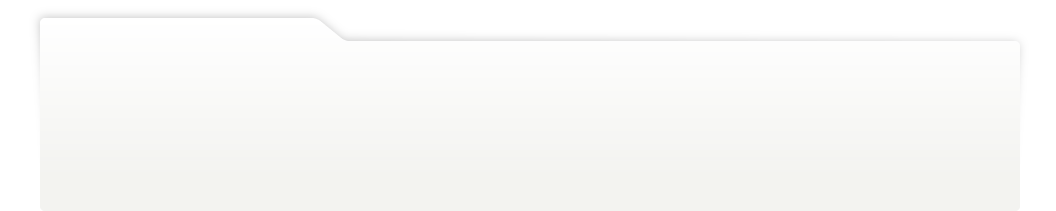
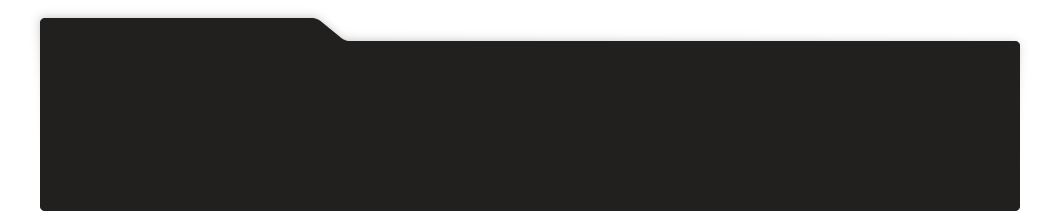
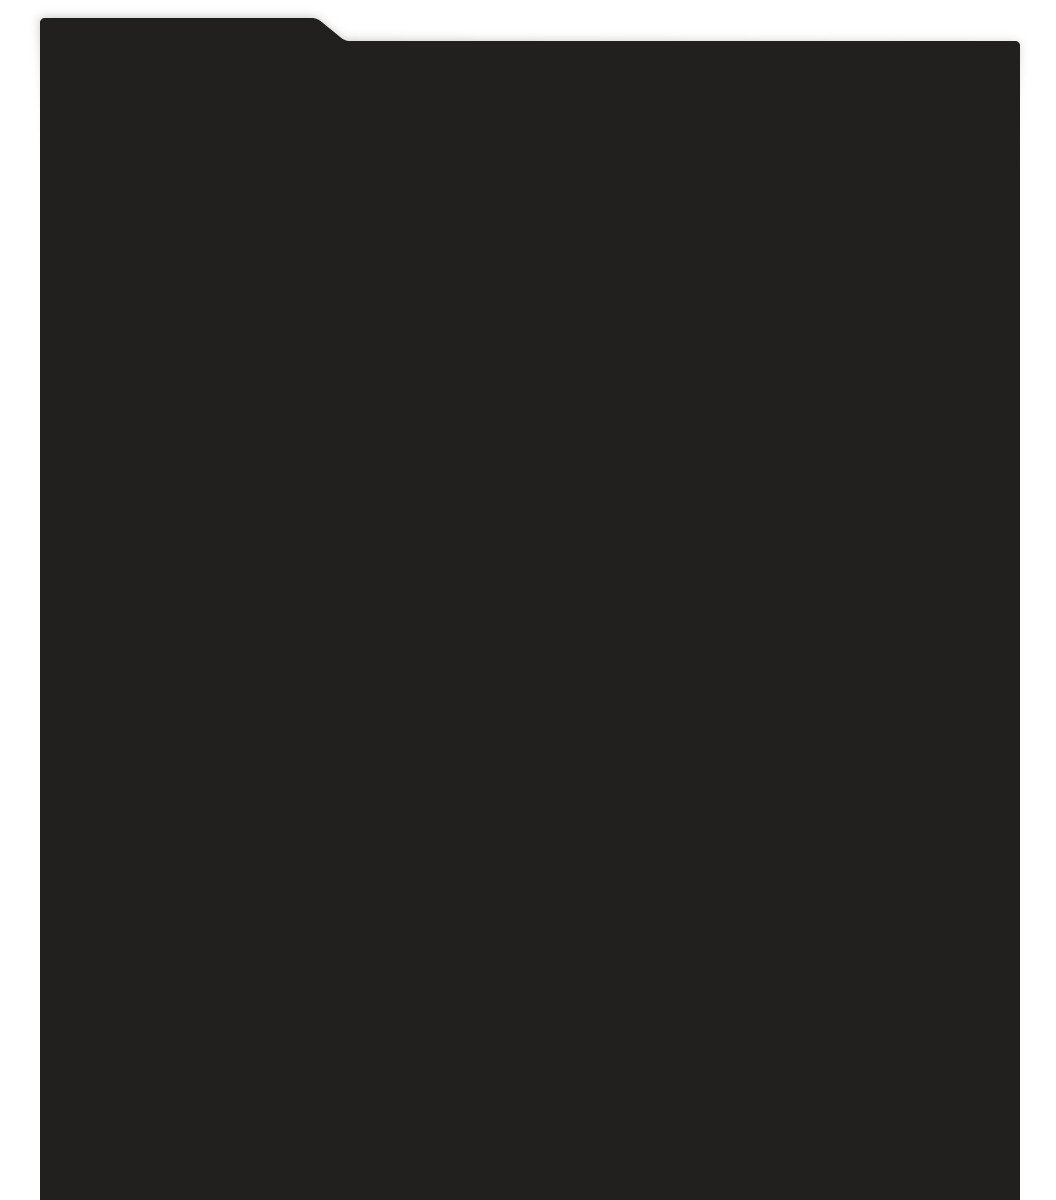
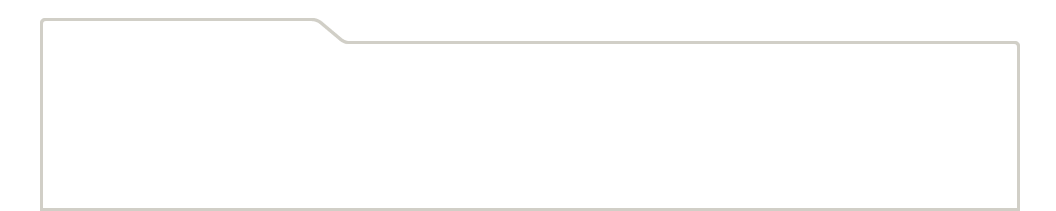
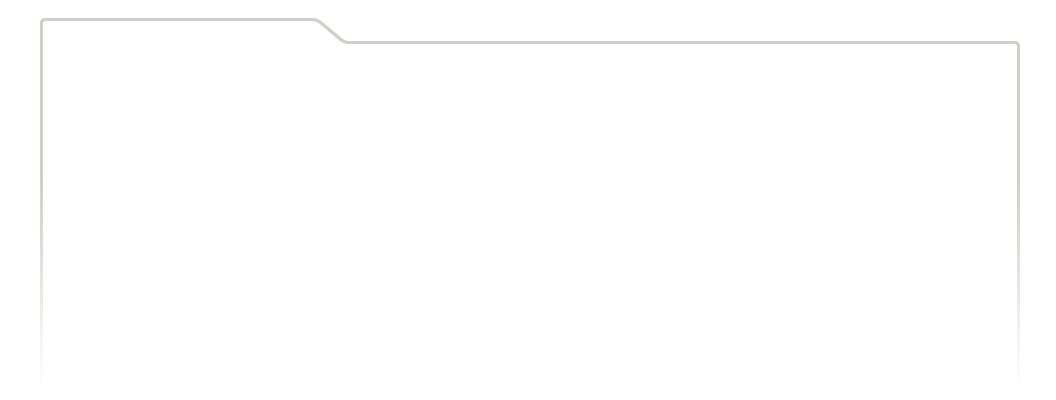
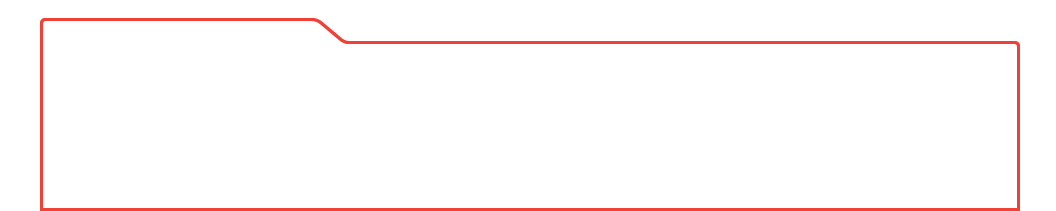
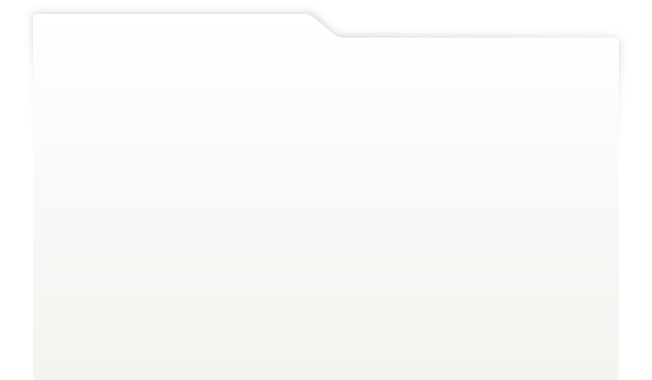
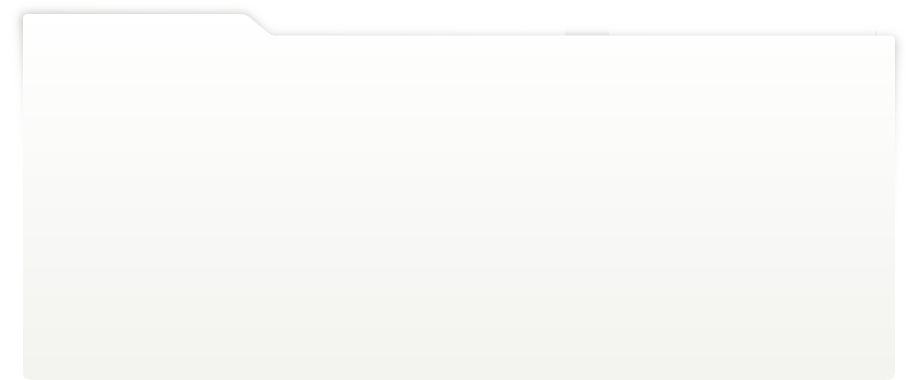
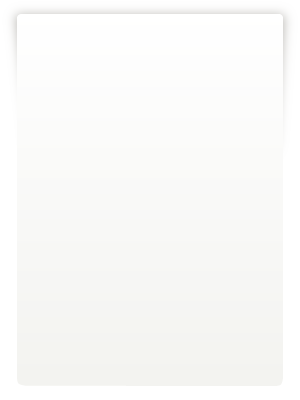
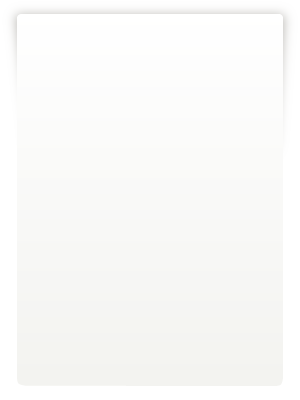
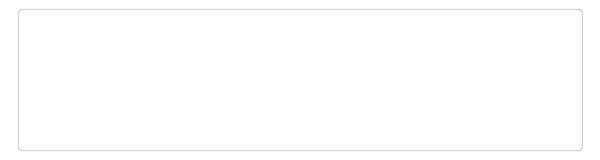
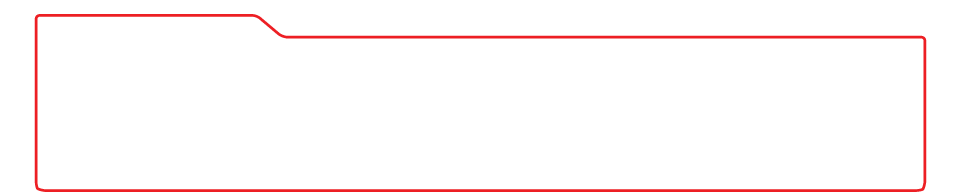
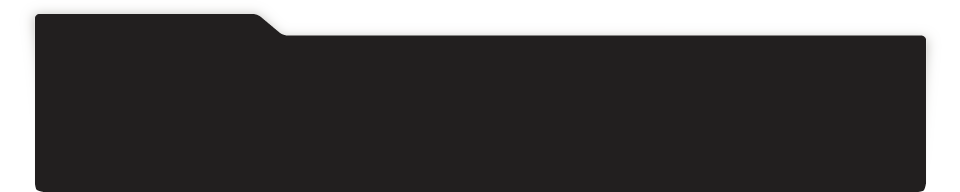
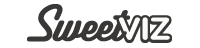
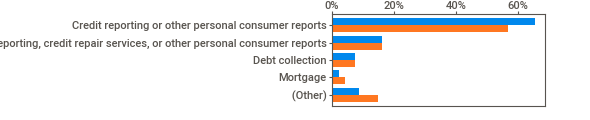
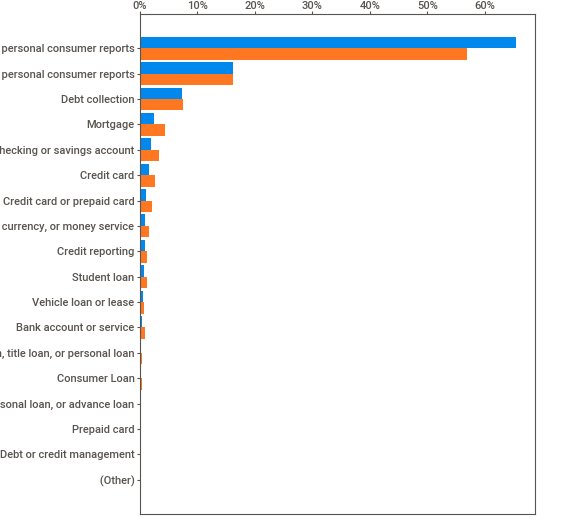
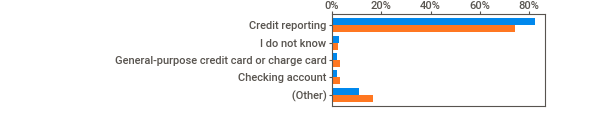
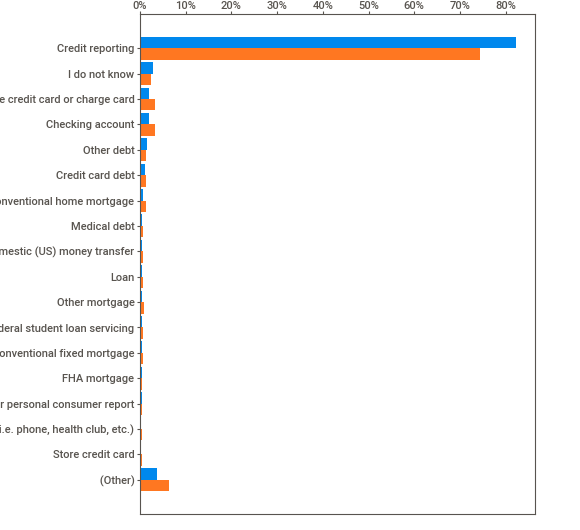
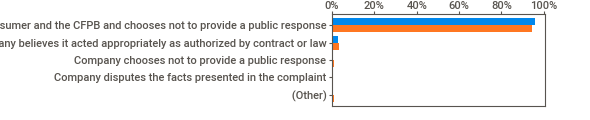
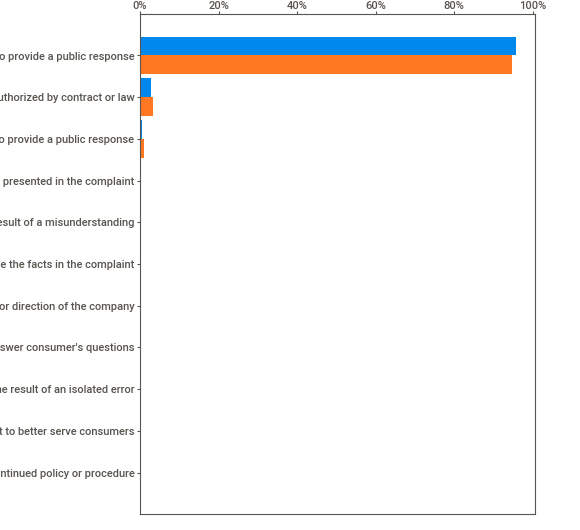
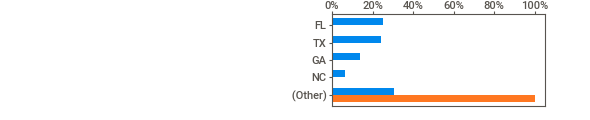
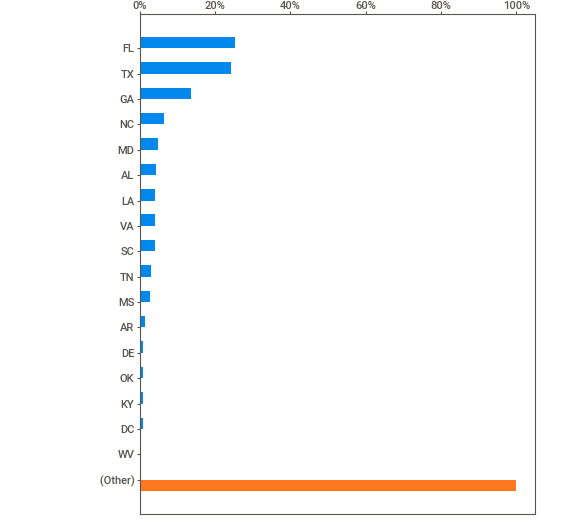
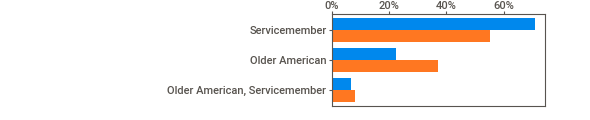
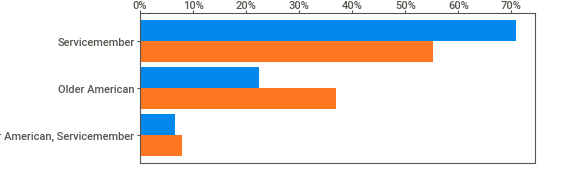
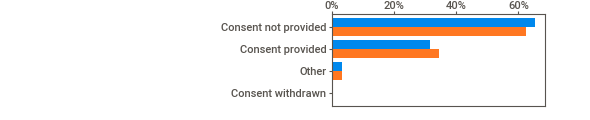
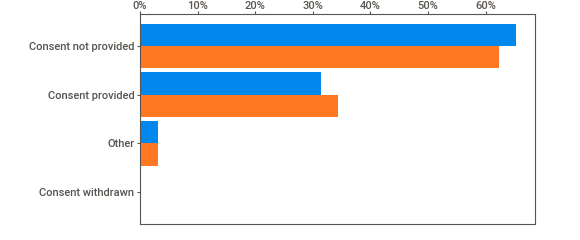
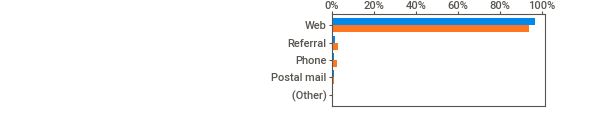
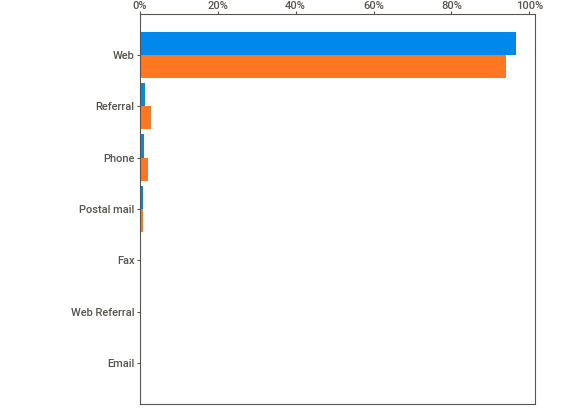
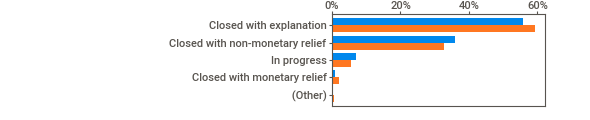
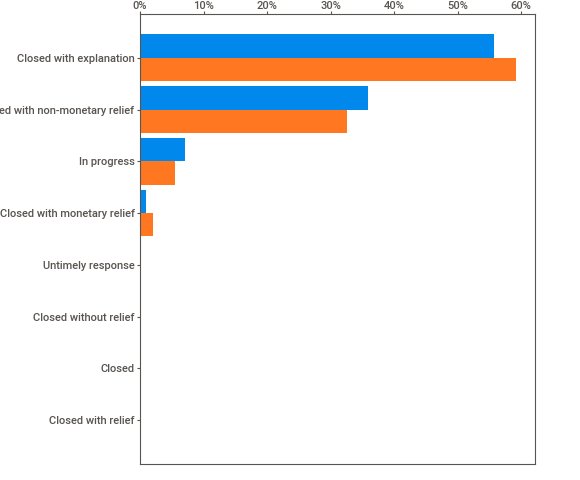
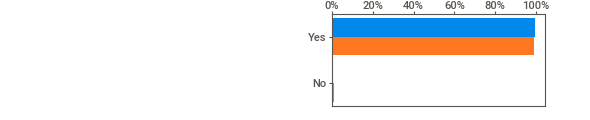
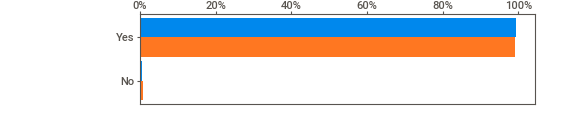
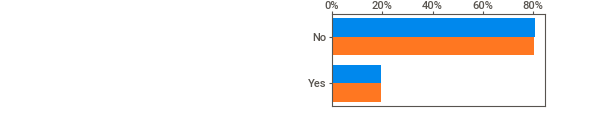
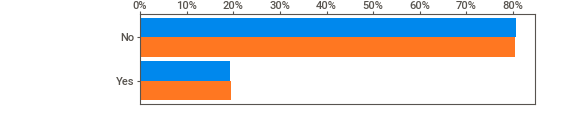
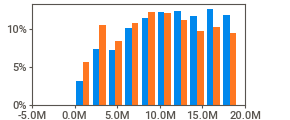
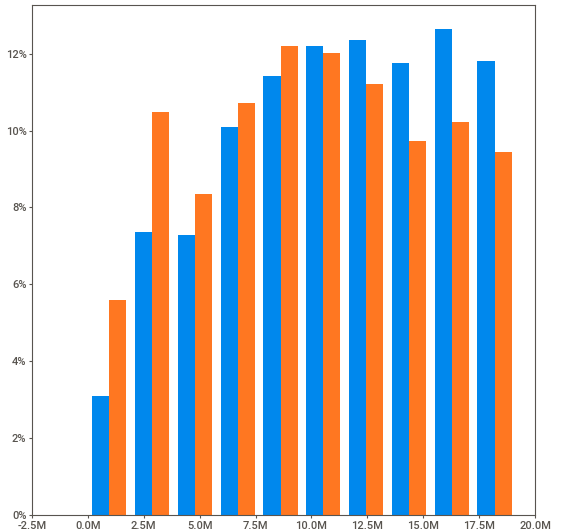
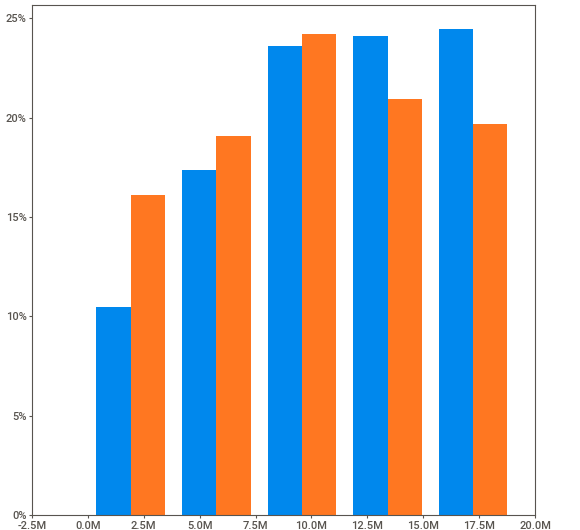
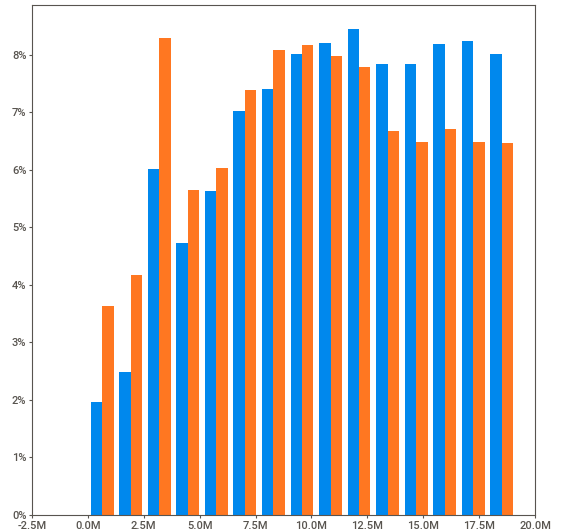
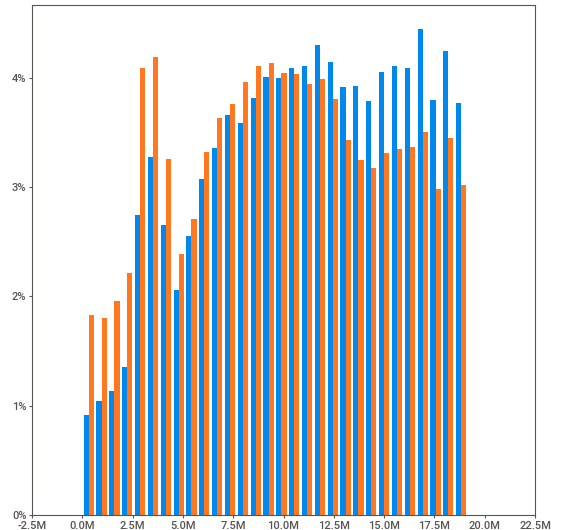
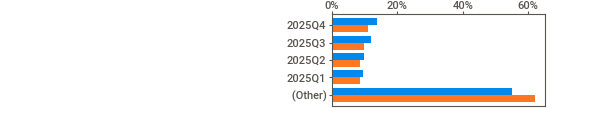
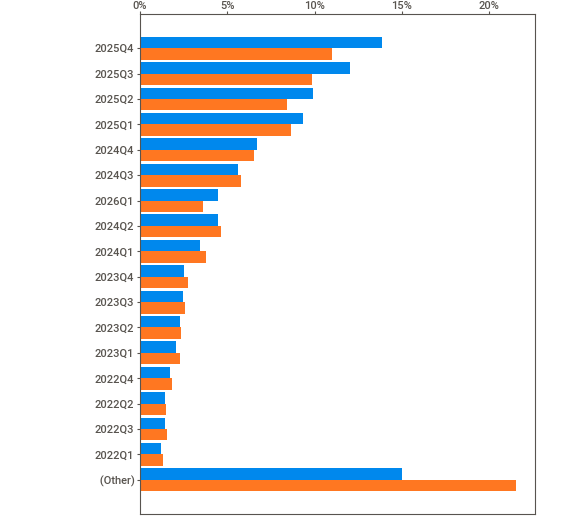
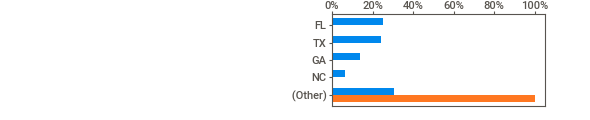
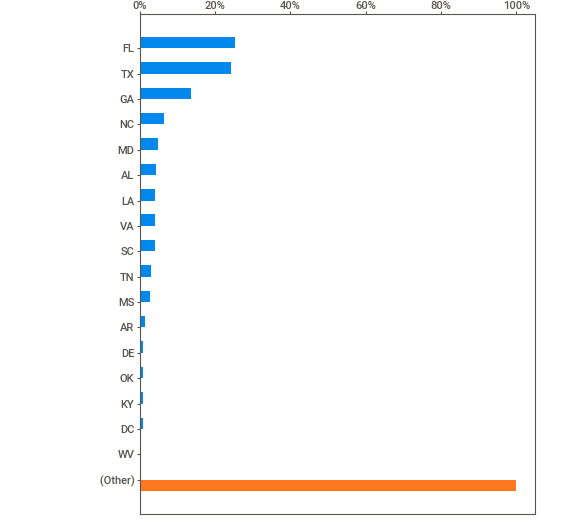
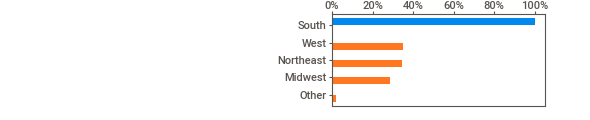
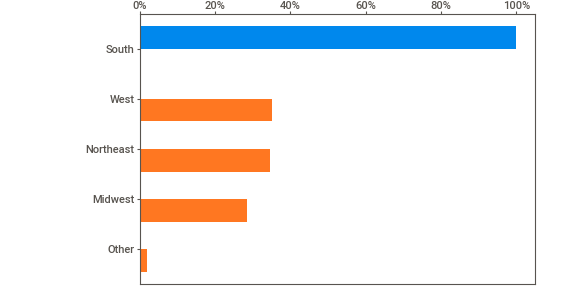
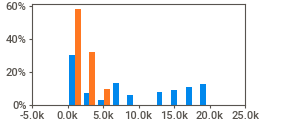
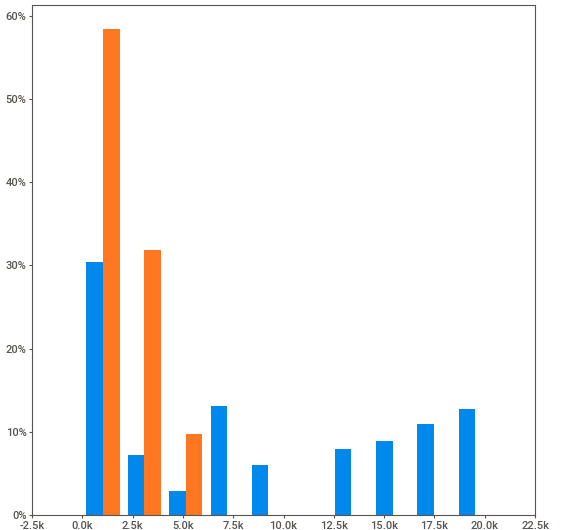
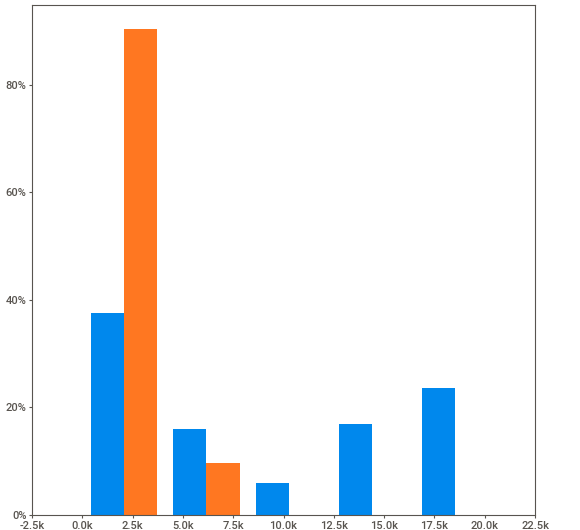
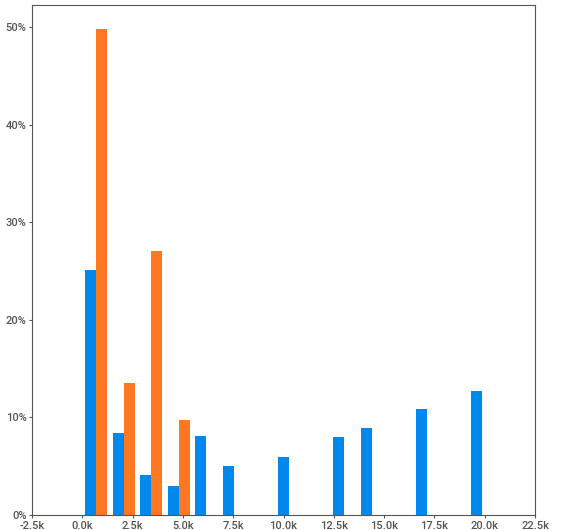
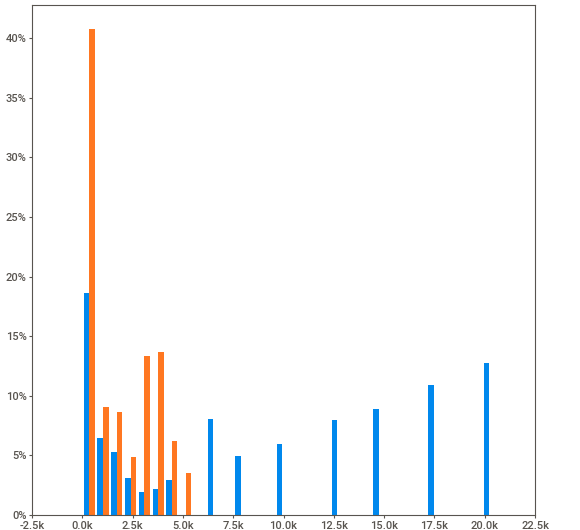
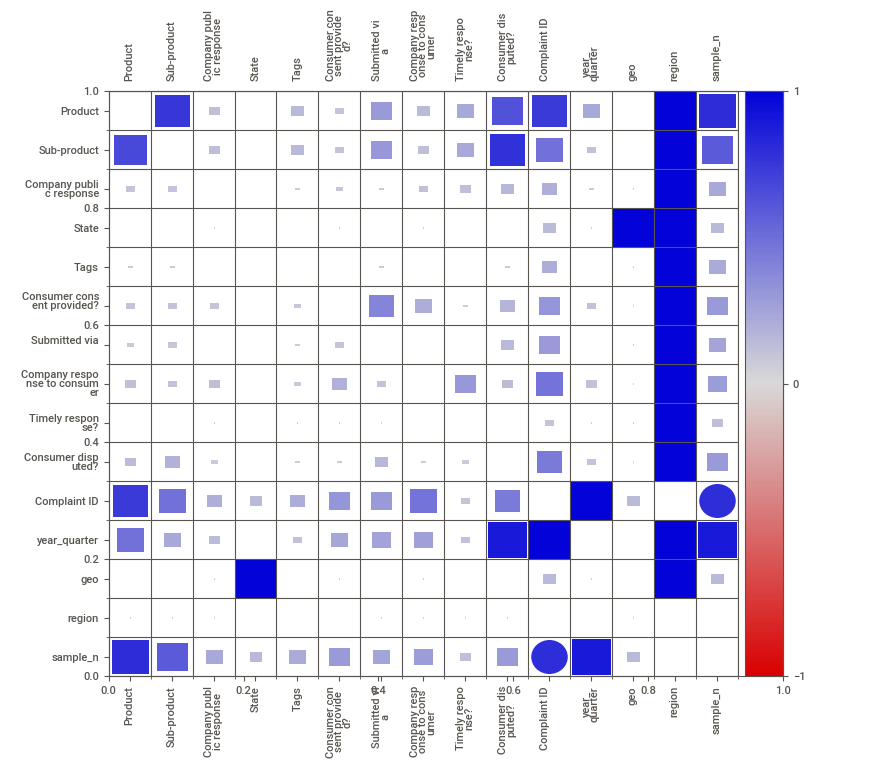
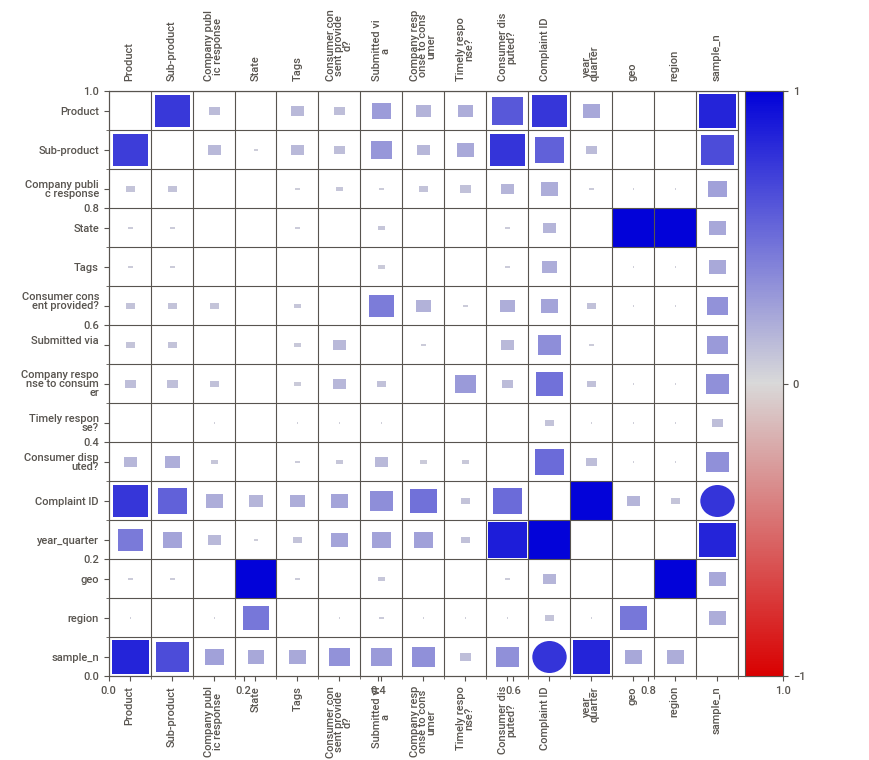

In [13]:
# Notebook iframe
sweet_report.show_notebook(scale=0.9)

In [11]:
sweet_report.show_html('../reports/south_vs_others_sweetviz.html')

Report ../reports/south_vs_others_sweetviz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### South vs Others: Review Summary

The South segment shows measurable composition differences that are relevant for modeling and policy interpretation.

Key takeaways:
- Debt-collection-related categories are elevated in South relative to Others.
- Geographic concentration is strongest in large Sunbelt states, especially TX and FL.
- Response timeliness remains high overall, but small directional gaps suggest potential operational variation.

Implications for notebooks 03-04:
- Segment-specific behavior supports separate regional evaluation in time-series workflows.
- South-focused monitoring is justified where complaint categories and growth patterns diverge from the rest of the portfolio.
- Findings should be interpreted as descriptive evidence from the sampled dataset, not causal inference.